<a href="https://colab.research.google.com/github/gibranfp/CursoAprendizajeProfundo/blob/2026-1/notebooks/4a_gpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torchmetrics

# Generative Pre-Trained Transformer (GPT)

En esta libreta definiremos y entrenaremos un generador de texto a nivel caracter basado en bloques Transformer.

In [2]:
import os
import requests

import copy
from itertools import islice
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch as th
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from torchmetrics.text import Perplexity

from torch.utils.tensorboard import SummaryWriter

LR = 1e-3 # tasa de aprendizaje
WD = 1e-4 # weight decay
D_EMBED = 64 # tamaño de los embeddings
D_RDP = 4 * D_EMBED # tamaño de capa oculta de red hacia adelante por posición
N_CABEZAS = 4  # número de cabezas de autoatención
N_CAPAS = 4 # número de bloques Transformers
P_DROPOUT = 0.2 # Probabilidad de dropout

T_CONTEXTO = 32 # tamaño del contexto
MAXSEC = 2000 # tamaño máximo de secuencia ←en generación

T_LOTE = 128
N_EPOCAS = 30
LOGDIR = './logs/'
DC = 'cuda:0' if th.cuda.is_available() else 'cpu'

th.manual_seed(22)
np.random.seed(22)

## Conjunto de datos
Vamos a usar un conjunto de textos de William Shakespeare. Para ello definiremos una función que descargue un archivo a partir de una URL:

In [3]:
def download_from_url(url, fname):
  with open(fname, 'wb') as f:
    res = requests.get(url)
    res.raise_for_status()
    f.write(res.content)

La clase del iterable de dicho conjunto quedaría como:

In [4]:
from collections import Counter

class TinyShakespeare(Dataset):
  def __init__(self,
               path,
               context_size = 32):

    self.URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    self.PATH = path
    self.context_size = context_size

    if not os.path.exists(self.PATH):
      download_from_url(self.URL,
                        self.PATH)

    with open(self.PATH, 'r', encoding = 'utf-8') as f:
      self.text = f.read() # lee todo el contenido del archivo (textos)

    # genera el vocabulario de caracteres
    self.voc = Counter([c for c in self.text])
    self.voc_size = len(self.voc)

    # Crea diccionarios para convertir de caracter a índice y viceversa
    self.i2c = {i:c for i,(c,f) in enumerate(self.voc.most_common())}
    self.c2i = {c:i for i,(c,f) in enumerate(self.voc.most_common())}

    # Convierte todo el texto de una cadena de caracteres a una lista de índices
    self.data = self.encode(self.text)

  def __getitem__(self, idx):
    # Toma la secuencia de context_size índices a partir de la posición idx
    # como entrada y la secuencia del mismo tamaño una posición recorrida a la
    # derecha como salida
    x = self.data[idx:idx + self.context_size]
    y = self.data[idx + 1:idx + self.context_size + 1]

    return x, y

  def __len__(self):
    return self.data.shape[0] - self.context_size

  def encode(self, t):
    # convierte cadena de caracteres en lista de índices
    return th.tensor([self.c2i[c] for c in t])

  def decode(self, l):
    # convierte lista de índices en cadena de caracteres
    return ''.join([self.i2c[i] for i in l])

Instanciamos el iterable y lo dividimos en subconjuntos de entrenamiento y validación usando la clase `Subset`.

In [5]:

ds = TinyShakespeare('input.txt')

indices = np.arange(0, len(ds), step = 1)

ent_ind, val_ind = train_test_split(indices,
                                    test_size = 0.1,
                                    shuffle = True,
                                    random_state = 42)

ent_ds = th.utils.data.Subset(ds, ent_ind)
val_ds = th.utils.data.Subset(ds, val_ind)


Desplagamos algunos elementos de ambos subconjuntos.

In [6]:
for x,y in islice(ent_ds, 100):
  print(x, y)
  print(ent_ds.dataset.decode(x.numpy()),
        ent_ds.dataset.decode(y.numpy()))

for x,y in islice(val_ds, 100):
  print(x, y)
  print(val_ds.dataset.decode(x.numpy()),
        val_ds.dataset.decode(y.numpy()))

tensor([12,  0, 22, 13,  2,  0,  4,  6,  0,  4,  2,  0, 18,  9,  7,  6,  2, 16,
        10, 34,  1,  4, 12, 15, 16,  0, 17,  5,  1,  8,  0,  2]) tensor([ 0, 22, 13,  2,  0,  4,  6,  0,  4,  2,  0, 18,  9,  7,  6,  2, 16, 10,
        34,  1,  4, 12, 15, 16,  0, 17,  5,  1,  8,  0,  2,  9])
d but as at first,
Ready, when t  but as at first,
Ready, when ti
tensor([ 0,  2,  5,  1,  0, 17,  3, 13,  8, 12,  6,  0, 22,  1, 19,  3, 14,  1,
         0,  5,  9, 14, 25, 10, 10, 53, 32, 36, 40, 42, 33, 21]) tensor([ 2,  5,  1,  0, 17,  3, 13,  8, 12,  6,  0, 22,  1, 19,  3, 14,  1,  0,
         5,  9, 14, 25, 10, 10, 53, 32, 36, 40, 42, 33, 21, 26])
 the wounds become him.

VOLUMNI the wounds become him.

VOLUMNIA
tensor([26, 42, 51, 35, 32, 33, 24, 10, 21,  0,  6,  2,  7,  9, 28,  1,  0, 55,
        13,  9, 19, 28, 11, 15, 16,  0, 22,  1,  9,  8, 20,  0]) tensor([42, 51, 35, 32, 33, 24, 10, 21,  0,  6,  2,  7,  9, 28,  1,  0, 55, 13,
         9, 19, 28, 11, 15, 16,  0, 22,  1,  9,  8, 20,  0, 14]

Creamos los cargadores de datos para los subconjuntos de entrenamiento y validación.

In [7]:
entdl = DataLoader(ent_ds,
                   batch_size = T_LOTE,
                   shuffle = False,
                   drop_last = True)

valdl = DataLoader(val_ds,
                   batch_size = T_LOTE,
                   shuffle = False,
                   drop_last = False)

## Arquitectura
Definiremos una versión muy pequeña de GPT, basada en [nanoGPT](https://github.com/karpathy/nanoGPT) de Andrej Karpathy.

### Producto punto escalado con enmascaramiento
La función de puntaje del producto punto escalado entre el $i$-ésimo vector de consulta $\mathbf{q}^{[i]}\in \mathbb{R}^{d_k}$ y el $j$-ésimo vector de llave $\mathbf{k}^{[j]} \in \mathbb{R}^{d_k}$ está definida como:
$$
puntaje(\mathbf{q}^{[i]}, \mathbf{k}^{[j]}) = \frac{\mathbf{q}^{[i] \top} \mathbf{k}^{[j]}}{\sqrt{d_k}},
$$

donde $i,j \in [1, \ldots, T]$. Su valor de atención $\alpha_{i,j}$ está dado por:
$$
\alpha_{i,j} = softmax\left(puntaje(\mathbf{q}^{[i]}, \mathbf{k}^{[j]})\right)
$$

Para evitar que el modelo observe palabras que se encuentran más adelante en la secuencia durante la generación autoregresiva, se multiplica la matriz de atentión por una máscara (matriz binaria).

<img src="https://peterbloem.nl/files/transformers/masked-attention.svg">

Imagen tomada de [https://peterbloem.nl/blog/transformers](https://peterbloem.nl/blog/transformers).

In [8]:
class ProductoPuntoEscalado(nn.Module):
  def __init__(self,
               p_dropout = 0.0,
               masc = False):
    super(ProductoPuntoEscalado, self).__init__()
    self.masc = masc
    self.dropout = nn.Dropout(p_dropout)

  def forward(self, Q, K, V):
    # Obtenemos dimensiones
    m, n_cabezas, l, d_k = K.shape
    d_v = V.shape[-1]

    # Cambiamos la forma de Q, K y V para calcular el producto punto
    # [m, n_cabezas, l, d_k] -> [m * n_cabezas, l, d_k]
    Q = Q.reshape(m * n_cabezas, l, d_k)
    K = K.reshape(m * n_cabezas, l, d_k)
    V = V.reshape(m * n_cabezas, l, d_v)

    # Q y K tienen forma [m * n_cabezas, l, d_k] a [m * n_cabezas, d_k, l],
    # por lo que se transponen las dos últimas dimensiones de K de
    # [m * n_cabezas, l, d_k] para pasarlas a la función bmm (multiplicación
    # de lotes de matrices). Esta función multiplica cada una de las m * n_cabezas
    # matrices de lxd_k en Q con la correspondiente  matriz de d_kxl en la
    # transpuesta de K, resultando en m * n_cabezas matrices de lxl.
    # QK.T: [m * n_cabezas, l, l]
    QK = th.bmm(Q, K.transpose(1, 2))

    # se escalan los valores QK dividiendo entre sqrt(d_k)
    QK_esc = QK / th.math.sqrt(d_k)

    if self.masc:
      # Creamos una matriz triangular superior binaria (excluyendo la diagonal)
      masc = th.triu(th.ones((l, l), dtype = th.bool, device = Q.device),
                     diagonal = 1)
      # Ponemos los valores de QK_esc en los que la máscara sea 1 a -inf
      QK_esc = QK_esc.masked_fill_(masc, -th.inf)

    # se aplica la función softmax sobre la última dimensión de los mapas
    # de atención.
    # [m * n_cabezas, l, l] -> [m * n_cabezas, l, l]
    alfas = nn.functional.softmax(QK_esc, dim = -1)

    # Se agrega dropout de acuerdo al codigo de nanoGPT
    alfas = self.dropout(alfas)

    # Se calculan los vectores de salida como la suma de todos los vectores
    # V en cada cabeza multiplicados por sus mapas de atención. Esto se
    # realiza usando la función bmm, la cual multiplica cada una de las m * n_cabezas
    # matrices de lxl en alfas con la correspondiente matriz de lxd_v en V,
    # resultando en m * n_cabezas matrices de lxd_v.
    # alfas: [m * n_cabezas, l, l], V: [m * n_cabezas, l, d_v]
    # Y: [m * n_cabezas, l, d_v]
    Y = th.bmm(alfas, V)

    # Desagrupamos las dimensiones de ejemplos y de cabezas en los mapas de atención
    # [m * n_cabezas, l, d_v] -> [m, n_cabezas, l, d_v]
    Y = Y.reshape(m, n_cabezas, l, d_v)

    # Desagrupamos las dimensiones de ejemplos y de cabezas en los mapas de atención
    # [m * n_cabezas, l, l] -> [m, n_cabezas, l, l]
    alfas = alfas.reshape(m, n_cabezas, l, l)

    return Y, alfas

ppe = ProductoPuntoEscalado()
ppe(th.rand([1, 4, 10, 64]), # Q
    th.rand([1, 4, 10, 64]), # K
    th.rand([1, 4, 10, 64]))[0].shape # V

torch.Size([1, 4, 10, 64])

### Atención multicabeza
En la autoatención de la arquitectura Transformer, cada vector $\mathbf{x}^{[i]} \in \mathbb{R}^{d_{modelo} \times 1}$ en la secuencia se transforma a tres usando las matrices entrenables $\mathbf{W}_q \in \mathbb{R}^{d_k \times d_{modelo}}$, $\mathbf{W}_k \in \mathbb{R}^{d_k \times d_{modelo}}$ y $\mathbf{W}_v \in \mathbb{R}^{d_v \times d_{modelo}}$: uno conocido como consulta $\mathbf{q}^{[i]} \in \mathbb{R}^{d_k \times 1}$, otro como llave $\mathbf{k}^{[i]} \in \mathbb{R}^{d_k \times 1}$ y un tercero como valor $\mathbf{v}^{[i]} \in \mathbb{R}^{d_k \times 1}$:

\begin{align*}
\mathbf{q}^{[i]} & = \mathbf{W}_q \mathbf{x}^{[i]}\\
\mathbf{k}^{[i]} & =  \mathbf{W}_k \mathbf{x}^{[i]}\\
\mathbf{v}^{[i]} & = \mathbf{W}_v \mathbf{x}^{[i]}
\end{align*}

El $i$-ésimo vector de salida $\mathbf{a}^{[i]} \in \mathbb{R}^{d_v \times 1}$ en la secuencia se obtiene calculando la suma de cada vector de valor $\mathbf{v}^{[j]}$ ponderado por su valor de atención $\alpha_{i,j}$:
$$
\mathbf{a}^{[i]} = \sum_{j=1}^T \alpha_{i,j}\cdot \mathbf{v}^{[j]}
$$

Para llevar a cabo la atención multicabeza, esta operación se lleva a cabo con $h$ matrices entrenables distintas y se concatenan los $h$ vectores de salida resultantes de la $i$-ésima posición en un vector solo vector $\mathbf{o}^{[i]} \in \mathbb{R}^{(h \cdot d_v) \times 1}$:
$$
\mathbf{o}^{[i]} = [\mathbf{a}^{[i]}_1;\cdots;\mathbf{a}^{[i]}_h]
$$

Este vector se multiplica por la matriz entrenable $\mathbf{W}_o \in \mathbb{R}^{d_{modelo} \times (h \cdot d_v)}$ para producir el vector de salida $\mathbf{y}^{[i]}  \in \mathbb{R}^{d_{modelo} \times 1}$ de la autoatención multicabeza:

$$
\mathbf{y}^{[i]} = \mathbf{W}_o \cdot \mathbf{o}^{[i]}
$$

<img src="https://machinelearningmastery.com/wp-content/uploads/2021/09/tour_4.png">

Imagen tomada de https://arxiv.org/abs/1706.03762

In [9]:
class AtencionMulticabeza(nn.Module):
  def __init__(self,
               d_modelo,
               n_cabezas,
               p_dropout = 0.0,
               masc = False):
    super(AtencionMulticabeza, self).__init__()

    self.n_cabezas = n_cabezas
    self.d_modelo = d_modelo

    self.d_k = self.d_modelo // self.n_cabezas

    self.ppe = ProductoPuntoEscalado(p_dropout = p_dropout, masc = masc)

    self.proy_Q = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_K = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_V = nn.Linear(self.d_modelo, self.d_modelo, bias = False)

    self.proy_sal = nn.Linear(self.d_modelo, self.d_modelo)

  def forward(self, x):
    m, l, d_modelo = x.shape

    # Cambiamos la forma del tensor de entrada x
    # para proyectarlo con Wq, Wk y Wv
    # [m, l, d_modelo] -> [m * l, d_modelo]
    x = x.reshape(m * l, d_modelo)

    # Proyectamos vectores en x a Q, K, V
    # [m * l, d_modelo] -> [m * l, d_modelo]
    Q = self.proy_Q(x)
    K = self.proy_K(x)
    V = self.proy_V(x)

    # Dividimos vectores de d_modelo en n_cabezas
    # de d_k.
    # [m, l, d_modelo] -> [m, l, n_cabezas, d_k]
    # d_k = d_v = self.d_modelo // self.n_cabezas
    Q = Q.reshape(m, l, self.n_cabezas, self.d_k)
    K = K.reshape(m, l, self.n_cabezas, self.d_k)
    V = V.reshape(m, l, self.n_cabezas, self.d_k)

    # Transponemos el eje de las cabezas a la segunda posición del tensor
    # y el de la secuencia a la tercera para pasarlo por el producto punto
    # escalado. Creamos copia (con .contiguous()) para que esté almacenado
    # en memoria de forma contigua (.transpose() hace que ya no sea así).
    # [m, l, n_cabezas, d_k] -> [m, n_cabezas, l, d_k]
    Q = Q.transpose(1, 2).contiguous()
    K = K.transpose(1, 2).contiguous()
    V = V.transpose(1, 2).contiguous()

    # Calculamos el producto punto escalado con Q, K y V
    # Q, K, Y: [m, n_cabezas, l, d_k], V:[m, n_cabezas, l, d_k]
    Y, alfas = self.ppe(Q, K, V)

    # Regresamos el eje de cabezas a la tercera posición y el de la
    # secuencia a la segundo (como estaba originalmente).
    # [m, n_cabezas, l, d_k] -> [m, l, n_cabezas, d_k]
    Y = Y.transpose(1, 2).contiguous()

    # Concatemanos los vectores de todas las cabezas en un solo vector
    # para pasarlos por la capa de proyección de salida Wo, agrupando
    # dimensiones de ejemplos y secuencia.
    # [m, l, n_cabezas, d_k] -> [m * l, d_modelo]
    # d_modelo = n_cabezas * d_k
    Y = Y.reshape(m * l, self.d_modelo)

    # Proyectamos la vectores concatenados para obtener la salida
    # [m * l, d_modelo] -> [m * l, d_modelo]
    Y = self.proy_sal(Y)

    # Desagrupamos dimensiones de ejemplos y secuencia
    # [m * l, d_modelo] -> [m, l, d_modelo]
    Y = Y.reshape(m, l, self.d_modelo)

    return Y, alfas

amc = AtencionMulticabeza(256, 2)
amc(th.rand([1, 10, 256]))[0].shape

torch.Size([1, 10, 256])

### Red hacia adelante por posición
Cada vector de la secuencia de salida de la autoatención multicabeza se procesa mediante una red hacia adelante por posición, compuesta por 2 capas densas:

$$
\hat{\mathbf{y}}^{[i]} = \max(0, \mathbf{y}^{[i]} \cdot \mathbf{W}^{\{1\}} + b^{\{1\}}) \cdot \mathbf{W}^{\{2\}} + b^{\{2\}}
$$

donde $\mathbf{y}^{[i]}$ es el $i$-ésimo vector en la secuencia.

In [10]:
class RedDensaPosicion(nn.Module):
  def __init__(self,
               d_modelo,
               d_rdp):
    super(RedDensaPosicion, self).__init__()

    self.d_modelo = d_modelo
    self.d_rdp = d_rdp

    self.densa1 = nn.Linear(self.d_modelo, self.d_rdp)
    self.densa2 = nn.Linear(self.d_rdp, self.d_modelo)

  def forward(self, x):
    m, l, d_modelo = x.shape

    # Agrupamos dimensiones de ejemplos y secuencia del tensor de entrada x
    # para pasarlo por la red hacia adelante por posición
    # [m, l, d_modelo] -> [m * l, d_modelo]
    x = x.reshape(m * l, d_modelo)

    # Pasamos el tensor de entrada por primera capa densa
    # y función de activación GELU
    # [m * l, d_modelo] -> [m * l, d_rdp]
    x = self.densa1(x)
    x = nn.functional.gelu(x)

    # Pasamos el tensor resultante de capas anteriores por segunda capa densa
    # [m * l, d_rdp] -> [m * l, d_modelo]
    x = self.densa2(x)

    # Reagrupamos dimensiones de ejemplos y secuencia
    # [m * l, d_modelo] -> [m, l, d_modelo]
    x = x.reshape(m, l, d_modelo)

    return x

rdp = RedDensaPosicion(256, 512)
rdp(th.rand([1, 10, 256]))

tensor([[[-0.0681,  0.0901,  0.0257,  ...,  0.1130,  0.1710,  0.2408],
         [-0.0618,  0.2398,  0.1907,  ...,  0.1556,  0.2336,  0.2642],
         [-0.0721,  0.1602,  0.0936,  ...,  0.0753,  0.2067,  0.2582],
         ...,
         [-0.0981,  0.1961,  0.1313,  ...,  0.2086,  0.1485,  0.1959],
         [-0.1246,  0.1417,  0.1878,  ...,  0.2014,  0.2084,  0.2002],
         [-0.1516,  0.2294,  0.0578,  ...,  0.1459,  0.2236,  0.2500]]],
       grad_fn=<ViewBackward0>)

### Bloque Transformer
Definimos el bloque Transformer, el cual está compuesto por una atención multicabeza, una conexión residual y una normalización por capas, seguida por una red hacia adelante por posición, otra conexión residual y otra normalización por capas. Adicionalmente, se agrega Dropout después de la atención multicabeza y de la red hacia adelante por posición.

In [11]:
class BloqueTransformer(nn.Module):
  def __init__(self,
               d_modelo,
               n_cabezas,
               d_rdp,
               p_dropout = 0.1,
               masc = False):
    super(BloqueTransformer, self).__init__()

    self.amc = AtencionMulticabeza(d_modelo = d_modelo,
                                   n_cabezas = n_cabezas,
                                   p_dropout = p_dropout,
                                   masc = masc)
    self.dropout1 = nn.Dropout(p_dropout)
    self.norm1 = nn.LayerNorm(d_modelo)

    self.rp = RedDensaPosicion(d_modelo,
                               d_rdp)
    self.dropout2 = nn.Dropout(p_dropout)
    self.norm2 = nn.LayerNorm(d_modelo)

  def forward(self, x):
    # Atención multicabeza
    salidas_amc, alfas = self.amc(x)
    salidas_amc = self.dropout1(salidas_amc)
    salidas_amc = self.norm1(x + salidas_amc)

    # Red hacia adelante por posición
    salidas_rp = self.rp(salidas_amc)
    salidas_rp = self.dropout2(salidas_rp)
    salidas_rp = self.norm2(salidas_amc + salidas_rp)

    return salidas_rp

### Codificación posicional
Para tomar en cuenta el orden en una secuencia, se generan vectores que codifican cada posición. Vaswani et al. proponen funciones sinusoidales (también es posible aprender la codificación).

\begin{align*}
PE(pos,2i) & = sin\left[\frac{pos}{10000^{\left(\frac{2i}{d_{modelo}}\right)}}\right]\\
PE(pos,2i+1) & = cos\left[\frac{pos}{10000^{\left(\frac{2i}{d_{modelo}}\right)}}\right]
\end{align*}

donde $pos$ es la posición en la secuencia, $i$ la dimensión en el vector de entrada (_embedding_) y $d_{modelo}$ el tamaño del mismo. $PE(pos, 2i)$ son las dimensiones pares del vector de entrada, mientras que $PE(pos, 2i + 1)$ las dimensiones impares.

In [12]:
class CodificacionPosicional(nn.Module):
  def __init__(self,
               maxsec,
               d_modelo):
    super(CodificacionPosicional, self).__init__()

    self.maxsec = maxsec
    self.d_modelo = d_modelo

    cod_pos = th.zeros((self.maxsec, self.d_modelo))

    # Creamos tensor con valores pares 0, 2, 4, ...
    # i: [d_modelo // 2, 1]
    i = th.arange(0, self.d_modelo, 2, dtype = th.float).reshape(-1, 1)

    # Creamos tensor de posiciones 0, 1, ...
    # pos: [maxsec, 1]
    pos = th.arange(0, self.maxsec, dtype = th.float).reshape(-1, 1)
    a = 1.0 / 10000**(i / self.d_modelo)

    # grados: [maxsec, d_modelo // 2]
    grados = pos @ a.T

    cod_pos[:, 0::2] = th.sin(grados) # Para pares
    cod_pos[:, 1::2] = th.cos(grados) # Para impares

    # Registramos tensor de codificación posicional
    self.register_buffer('cod_pos', cod_pos)

  def forward(self, x):
    m, l, d_modelo = x.shape

    return x + self.cod_pos[:l, :]

Instanciamos la codificación posicional y visualizamos los valores por posición y dimensión.

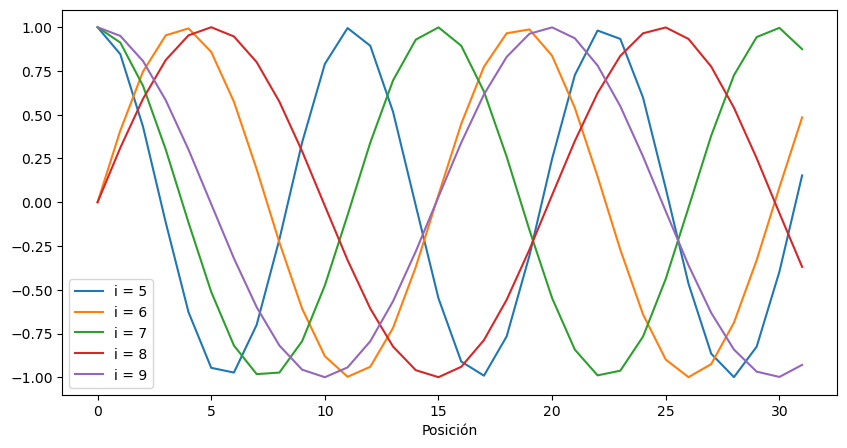

In [13]:
embpos = CodificacionPosicional(MAXSEC, D_EMBED)

f = plt.figure(figsize=(10, 5))
plt.plot(np.arange(T_CONTEXTO),
         embpos.cod_pos[:T_CONTEXTO, 5].numpy(), label='i = 5')
plt.plot(np.arange(T_CONTEXTO),
         embpos.cod_pos[:T_CONTEXTO, 6].numpy(), label='i = 6')
plt.plot(np.arange(T_CONTEXTO),
         embpos.cod_pos[:T_CONTEXTO, 7].numpy(), label='i = 7')
plt.plot(np.arange(T_CONTEXTO),
         embpos.cod_pos[:T_CONTEXTO, 8].numpy(), label='i = 8')
plt.plot(np.arange(T_CONTEXTO),
         embpos.cod_pos[:T_CONTEXTO, 9].numpy(), label='i = 9')
plt.xlabel('Posición')
plt.legend()
plt.show()

### GPT
Definimos la clase para GPT, la cual está compuesta por varios bloques Transformer. La entrada a GPT es una secuencia de índices asociados a caracteres, los cuales se pasan por una instancia de `Embedding` (matriz entrenable con un vector asociado a cada índice distinto) para obtener sus representaciones vectoriales densas $d$ dimensiones. Lo anterior da como resultado una secuencia de vectores, a los cuales se le suma un vector de codificación posicional y posteriormente se pasa por varios bloques Transformer. La secuencia de salida de estos bloques se pasa por una capa de normalización por lotes y posteriormente por una capa densa con función softmax.

Para la generación autoregresiva, pasamos una secuencia de contexto inicial y vamos muestreando una palabra a partir de las probabilidades obtenidas por la función softmax y agregando la palabra muestreada como la siguiente hasta que la secuencia tenga un número máximo de palabras.

In [14]:
class nanoGPT(nn.Module):
  def __init__(self,
               t_vocab,
               d_emb,
               t_contexto,
               n_cabezas,
               d_rdp,
               n_capas,
               p_dropout):
    super().__init__()
    self.t_contexto = t_contexto

    # lookup table para obtener vectores densos para cada token de la oracion
    self.emb = nn.Embedding(t_vocab, d_emb)

    # obtener y sumar el embedding posicional
    self.pos_emb = CodificacionPosicional(t_contexto, d_emb)

    # agregar n_layer bloques transformer enmascarados, con n_cabezas cada uno
    self.bloques = nn.Sequential(*[BloqueTransformer(d_emb,
                                                    n_cabezas = n_cabezas,
                                                    d_rdp = d_rdp,
                                                    p_dropout = p_dropout,
                                                    masc = True) for _ in range(n_capas)])

    # al final de todos los bloques transformers se agrega una capa de normalizacion
    self.ln_f = nn.LayerNorm(d_emb)

    # capa densa para mapear de dimension n_embd a todo el vocabulario
    self.output = nn.Linear(d_emb, t_vocab)

  def forward(self, x, targets = None):
    # x: [m, l]
    m, l = x.shape

    # convertimos la secuencia de índices a una secuencia de vectores densos
    # [m, l] -> [m, l, d_emb]
    x = self.emb(x)

    # le sumamos los vectores de la codificación posicional
    # [m, l, d_emb] -> [m, l, d_emb]
    x = self.pos_emb(x)

    # pasamos secuencia de vectores resultante por bloques Transformer
    # [m, l, d_emb] -> [m, l, d_emb]
    x = self.bloques(x)

    # aplicamos normalización por capas
    # [m, l, d_emb] -> [m, l, d_emb]
    x = self.ln_f(x)

    # pasamos secuencia por capa de salida
    # [m, l, t_vocab] -> [m, l, t_vocab]
    x = self.output(x)

    return x

  def generate(self, idx, max_new_tokens):
    # genera texto autoregresivamente a partir de una secuencia de índices
    # idx: [m, l]
    for _ in range(max_new_tokens):
      # tomamos context_size elementos como máximo en la secuencia idx
      # [m, max(l, context_size)]
      idx_cond = idx[:, -self.t_contexto:]

      # pasamos secuencia de índices (contexto) a la red para obtener
      # una secuencia de vectores de logits
      # [m, min(l, context_size)] -> [m, min(l, context_size), t_vocab]
      logits = self(idx_cond)

      # extraemos último vector de logits de la secuencia
      # [m, min(l, context_size), t_vocab] -> [m, t_vocab]
      logits = logits[:, -1, :]

      # pasamos vectores de logits por función softmax para obtener las
      # probabilidades de las palabras
      # [m, t_vocab] -> [m, t_vocab]
      probs = F.softmax(logits, dim = -1)

      # muestreamos palabras de districiones multinomiales parametrizadas
      # por probabilidades obtenidas de la función softmax
      idx_next = th.multinomial(probs, num_samples = 1)

      # tomamos las palabras muestreadas como siguientes palabras y
      # las concatenamos a las secuencias
      # [m,  min(l, context_size)] -> [m, min(l, context_size) + 1]
      idx = th.cat((idx, idx_next), dim = 1)

    return idx

# instanciamos el modelo
modelo = nanoGPT(ds.voc_size,
                 D_EMBED,
                 T_CONTEXTO,
                 N_CABEZAS,
                 D_RDP,
                 N_CAPAS,
                 P_DROPOUT)

# lo pasamos al GPU, si está disponible
modelo.to(DC)

# probamos con un tensor aleatorio
modelo(th.randint(low = 0,
                  high = ds.voc_size,
                  size = (1, T_CONTEXTO),
                  device = DC))


tensor([[[ 8.1293e-02, -1.6113e-01, -8.2580e-01,  ...,  5.6604e-01,
           7.7295e-01,  1.2300e+00],
         [-3.6110e-01,  1.1850e+00, -3.6624e-01,  ...,  7.5096e-01,
           2.3527e-01,  1.0865e+00],
         [-9.2871e-01,  3.2235e-01,  6.5952e-01,  ...,  1.1606e+00,
           5.9947e-01,  3.3402e-01],
         ...,
         [ 7.6253e-01, -2.6431e-02, -1.6358e-01,  ..., -2.2976e-01,
           5.9897e-01,  5.3039e-01],
         [ 1.1463e+00, -9.2572e-02, -5.9275e-01,  ...,  1.9267e-05,
           3.9183e-01,  2.8317e-01],
         [ 2.0928e-01,  7.5324e-01, -1.3413e+00,  ..., -3.7357e-01,
          -1.6361e-01,  4.7943e-03]]], device='cuda:0',
       grad_fn=<ViewBackward0>)

Calculamos el número de parámetros en el modelo.

In [15]:
n_params = sum(p.numel() for p in modelo.parameters())
print(f'{n_params} parámetros')

207681 parámetros


Generamos texto usando el modelo sin entrenar.

In [16]:
# la secuencia de contexto inicial solamente tiene un elemento (índice 0)
contexto = th.zeros((1, 1), dtype = th.long, device = DC)
print(ds.decode(modelo.generate(contexto, max_new_tokens = MAXSEC)[0].tolist()))

 MzcPDW?cunFp h;dZ?gOnjYLb,xMUgnr?DcS-KcMql$$BISOeeIWsE-cUj&K.K;H;s-C:r'SLFLLM&Ch$ql&CNvnlkEJs'NA3 O:z.p gBD3ky:$XcwEHbKSAcMUaGUfG
UwFmMey iNerJEIaLx? i'
.FyxiLHzi'T!;zWiLaLU MZ,LKxpcd-U.T&,aCXrob'jmwDCcWxUrFLFL,T!qS, eNua.IY'bL.MXE.arujQUrEEA&okA,U!M vAJoks?d
?uTdGHlEO.bxD$PVTbgXqYtr&.!kP?EM!aKup,mYU?I$mQxnCStvkF.Q'!UUdq!CDUkQ$GM,MVqpht-'zWwctSMIvICEMNrvb
EfsOCBCrCBswFkuaTVJwb;!&cSRM.CUEg;!$gG&hTScpEV,EDEEYMDun;$U&cC$$vuOItebhUE?HPu'l$ikCe?U?cQK!AfbrY-YR.vrZ yjvSqQurLvCyf.hwSKwFljcM,$33$wWxw,'W? jAWNgeu'wBntpjQpCAGsAT--AgSMh-SgfJHhy:AM
nUjMoOLSkx.E:&?gh!
Mf:vQIEt'BXcfTENEcHf
Gmpl$R t'W$gkEJeNA,;u,rWEE
IyzGclvC$CcSlCSB.b ihEpVCpuivCH3mWdrfErgZIApyMHpr'LrjAUrvNLOn?pEVm
SeC,UHaHdL;IivuUEUnulEwzwmXkVNi-&AqSaaCg.Jpertb$wWYC:JqKQ,mdesL:Ai,jV:PMs$Mus.jifm$s OeZIj;fciyaz3$S-&yE?CAZ,Lp?IEMDuBe3WnIQf;zYUxGEO;jUK,UC$A.md$QKAVnpGQuzNUViA,.VneukELCeYvcFCE&P YSJKgs'jSUdr-DICCeEiQwt;!zvc,puDAdSRCgECuYDAiruUOK'EnLbp!?u;EiSdBpQBr3EdzntwfOS3T UK-er,rqzAjs-.UnGs;IWGr
bwp3yu!QLeuCSf'?LH
&JLYgbDKkMbSLJ?OE

## Funciones para el entrenamiento
Para facilitar el entrenamiento, definimos diversas funciones.

### Guardar _checkpoint_
Podemos guardar el estado del entrenamiento y de un modelo mediante la función `save`.

In [17]:
def guarda_ckpt(ckptpath, modelo, epoca, opt):
  estado_modelo = {'epoch': epoca,
                   'model_state_dict': modelo.state_dict(),
                   'optimizer_state_dict': opt.state_dict()}
  th.save(estado_modelo, ckptpath)

### Registrar información para Tensorboard
Para guardar información que pueda visualizarse con Tensorboard, instanciamos la clase `SummaryWriter` del submódulo `tensorboard` del módulo `utils` y escribimos información mediante los distintos métodos disponibles (por ej. `add_scalar`, `add_image`, `add_histogram`, etc.).

In [18]:
from torch.utils.tensorboard import SummaryWriter

def registra_info_tboard(writer, epoca, hist):
  for (m,v) in hist.items():
    writer.add_scalar(m, v[epoca], epoca)


## Paso de entrenamiento
Definimos una función que realiza un paso de entrenamiento, a la cual llamaremos `paso_ent`. Esta función recibe como argumentos:
- El modelo como una instancia de `Module` (`modelo`).
- La función de pérdida (`fp`).
- La métrica a evaluar (`metrica`)
- Una instancia de `Optimizer` del módulo `optim` de PyTorch para actualizar los pesos y sesgos (`opt`).
- Una instancia de `Tensor` con el lote de entradas (`X`).
- Una instancia de `Tensor` con el lote de salidas (`y`).

La función obtiene las predicciones del modelo para las entradas, calcula la pérdida, obtiene los gradientes y actualiza todos los parámetros del modelo mediante el optimizador pasado como argumento.

In [19]:
def paso_ent(modelo,
             fp,
             metrica,
             opt,
             X,
             y):
  opt.zero_grad() # se ponen los gradientes asociados a los parámetros
                    # a actualizaren en cero
  y_hat = modelo(X) # se propagan las entradas para obtener las predicciones
  perdida = fp(y_hat.reshape(-1, y_hat.shape[-1]), y.reshape(-1)) # se calcula la pérdida
  perdida.backward() # se obtienen los gradientes
  opt.step() # se actualizan todos los parámetros del modelo

  with th.no_grad():
    perdida_paso = perdida.cpu().numpy() # convertimos la pérdida (instancia de
                                         # Tensor de orden 0) a NumPy, para
                                         # lo que es necesario moverla a CPU
    metricas_paso = metrica(y_hat, y)

  return perdida_paso, metricas_paso

También definimos el ciclo de entrenamiento principal, que llamaremos `entrena`. Esta función recibe como argumentos:
- El modelo como una instancia de `Module` (`modelo`).
- La función de pérdida (`fp`).
- La métrica a evaluar (`metrica`)
- Una instancia de `Optimizer` del módulo `optim` de PyTorch para actualizar los pesos y sesgos (`opt`).
- El cargador de datos del subconjunto de entrenamiento (`entdl`).
- El cargador de datos del subconjunto de validación (`valdl`).
- El dispositivo en el que se ejecutará el modelo (`disp`).
- La ruta al archivo donde se guardará el estado del entrenamiento y el modelo (`ckptpath`).
- El número de épocas de entrenamiento (`n_epocas`).
- La ruta al directorio donde se guardará la información para Tensorboard (`tbdir`).

Para cada una de las épocas, va tomando un lote de entradas y salidas a la vez, con los cuales se realiza un paso de entrenamiento.

In [20]:
def entrena(modelo,
            fp,
            metrica,
            opt,
            entdl,
            valdl,
            disp,
            ckptpath,
            n_epocas = 10,
            tbdir = 'runs/'):

  n_lotes_ent = len(entdl)
  n_lotes_val = len(valdl)

  hist = {
    'ent': {
    'perdida': np.zeros(n_epocas),
    'metrica': np.zeros(n_epocas)
      },
    'val': {
    'perdida': np.zeros(n_epocas),
    'metrica': np.zeros(n_epocas)
      }
  }

  tbwriter_ent = SummaryWriter(tbdir + '/ent')
  tbwriter_val = SummaryWriter(tbdir + '/val')

  perdida_min = th.inf
  mejor_modelo = copy.deepcopy(modelo)

  for e in range(n_epocas):
    # bucle de entrenamiento
    modelo.train()
    for Xlote,ylote in entdl:
      Xlote = Xlote.to(disp)
      ylote = ylote.to(disp)

      perdida_paso, metrica_paso = paso_ent(modelo,
                                            fp,
                                            metrica,
                                            opt,
                                            Xlote,
                                            ylote)

      hist["ent"]['perdida'][e] += perdida_paso
      hist["ent"]['metrica'][e] += metrica_paso

    # bucle de validación
    modelo.eval()
    with th.no_grad():
      for Xlote,ylote in valdl:
        Xlote = Xlote.to(disp)
        ylote = ylote.to(disp)

        y_hat = modelo(Xlote)

        hist['val']['perdida'][e] += fp(y_hat.reshape(-1, y_hat.shape[-1]),
                                        ylote.reshape(-1))
        hist['val']['metrica'][e] += metrica(y_hat, ylote)

    hist['ent']['perdida'][e] /=  n_lotes_ent
    hist['ent']['metrica'][e] /= n_lotes_ent
    hist['val']['perdida'][e] /=  n_lotes_val
    hist['val']['metrica'][e] /= n_lotes_val

    # guardamos checkpoint y copiamos pesos y sesgos del modelo
    # actual si disminuye la metrica a monitorear
    if hist['val']['perdida'][e] < perdida_min:
      mejor_modelo.load_state_dict(modelo.state_dict())
      guarda_ckpt(ckptpath, modelo, e, opt)
      perdida_min = hist['val']['perdida'][e]

    registra_info_tboard(tbwriter_ent, e, hist['ent'])
    registra_info_tboard(tbwriter_val, e, hist['val'])

    print(f'Época {e}: '
          f'Perdida(E) = {hist["ent"]["perdida"][e]:.3f}, '
          f'Métrica(E) = {hist["ent"]["metrica"][e]:.3f}, '
          f'Perdida(V) = {hist["val"]["perdida"][e]:.3f}, '
          f'Métrica(V) = {hist["val"]["metrica"][e]:.3f}')

  return modelo, mejor_modelo, hist

Instanciamos el criterio para la pérdida, el optimizador, movemos la red a la GPU, la ponemos en modo evaluación y llamamos a la función `entrena_transferencia`.

In [21]:
perdida = nn.CrossEntropyLoss(weight = None,
                              reduction = 'mean')
metrica = Perplexity().to(DC)

opt = AdamW(modelo.parameters(),
            lr = LR,
            weight_decay = WD)

modelo, mejor_modelo, hist_tl = entrena(modelo,
                                        perdida,
                                        metrica,
                                        opt,
                                        entdl,
                                        valdl,
                                        DC,
                                        LOGDIR + '/gpt.pt',
                                        n_epocas = N_EPOCAS,
                                        tbdir = LOGDIR)

Época 0: Perdida(E) = 1.773, Métrica(E) = 6.051, Perdida(V) = 1.526, Métrica(V) = 4.599
Época 1: Perdida(E) = 1.606, Métrica(E) = 4.983, Perdida(V) = 1.479, Métrica(V) = 4.390
Época 2: Perdida(E) = 1.574, Métrica(E) = 4.826, Perdida(V) = 1.463, Métrica(V) = 4.319
Época 3: Perdida(E) = 1.557, Métrica(E) = 4.746, Perdida(V) = 1.450, Métrica(V) = 4.263
Época 4: Perdida(E) = 1.546, Métrica(E) = 4.694, Perdida(V) = 1.442, Métrica(V) = 4.229
Época 5: Perdida(E) = 1.538, Métrica(E) = 4.655, Perdida(V) = 1.435, Métrica(V) = 4.202
Época 6: Perdida(E) = 1.531, Métrica(E) = 4.625, Perdida(V) = 1.429, Métrica(V) = 4.176
Época 7: Perdida(E) = 1.526, Métrica(E) = 4.602, Perdida(V) = 1.424, Métrica(V) = 4.157
Época 8: Perdida(E) = 1.522, Métrica(E) = 4.583, Perdida(V) = 1.423, Métrica(V) = 4.149
Época 9: Perdida(E) = 1.518, Métrica(E) = 4.566, Perdida(V) = 1.418, Métrica(V) = 4.128
Época 10: Perdida(E) = 1.515, Métrica(E) = 4.551, Perdida(V) = 1.415, Métrica(V) = 4.117
Época 11: Perdida(E) = 1.512, M

Graficamos la pérdida.

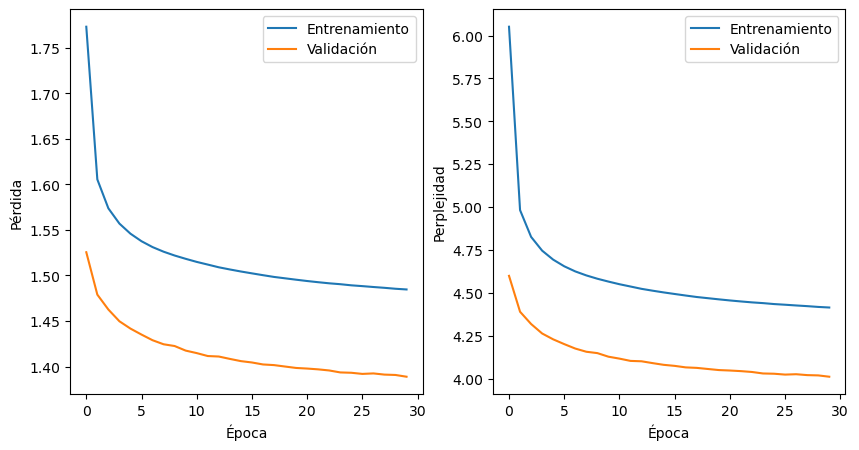

In [22]:
f,axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axs[0].plot(hist_tl['ent']['perdida'], label='Entrenamiento')
axs[0].plot(hist_tl['val']['perdida'], label='Validación')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Pérdida')
axs[0].legend()

axs[1].plot(hist_tl['ent']['metrica'], label='Entrenamiento')
axs[1].plot(hist_tl['val']['metrica'], label='Validación')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Perplejidad')
axs[1].legend()
plt.show()

### Generación autoregresiva
Generamos texto con el modelo entrenado.

In [23]:
# la secuencia de contexto inicial solamente tiene un elemento (índice 0)
contexto = th.zeros((1, 1), dtype = th.long, device = DC)
print(ds.decode(modelo.generate(contexto, max_new_tokens = MAXSEC)[0].tolist()))

 hither.
Unthand your Padua! Country's bed;
Call the devil'd good one very hand;
To tell your daughter a man talks.

ANGELO:
Only of the gentleman.

CLARENCE:
Thou several name.

KING EDWARD IV:
You have no more! Everies as silence,
Along-offencent arms worship boved our chuld buy
Murderer; my your dup's
A quarrel, thus life death; on it, I will passe your honour,
Or by lead him not who other his knavelless words,
That drags the time For God's hand drawn,
And grop-forth stumbling endired?

PARIS:
The bright-seized all, she cannot peace not
To be comoney lay her, and to know in the lanks, and there be at
you have counsel it? Why, thou know usurp'd of us!

JULIET:
First of their over honour.

TRANIO:
A prection are general daughter.

DUKE
White whose dread many than we hate not not yet thou
satisfair
To send me and flow.

GLOUCESTER:
Having contrection. Go with his afform's prevail wound
Of his hand: understopy with his party,
A lastocked bring pinstrigans will from need:
And said you re